Zadanie projektowe polega na wykonaniu w grupach 2-3 osobowych analizy statystycznej wybranego zbioru danych w oparciu o metody poznane na zajęciach. Należy wyznaczyć i zinterpretować podstawowe parametry statystyczne oraz uwzględnić co najmniej jedną metodę z każdej z grup:

  * testy parametryczne (t-studenta)
  * testy nieparametryczne (testy zgodności, nieparametryczne odpowiedniki testów t)
  * ANOVA
  * analiza regresji wielorakiej


# **1. Wprowadzenie**

## 1.1 Wczytanie zbioru i podstawowy opis danych

Dane pochodzą z Kaggle i są dostępne pod [tym adresem](https://www.kaggle.com/datasets/thedrzee/bmw-carsdataset "Link do zbioru BMW"). Zbiór zawiera nieco ponad 10,000 rekordów dotyczących używanych samochodów marki BMW.

Zbiór zawiera 9 kolumn:

*   **model** - marka samochodu
*   **year** - rok produkcji
*   **price** - cena [GBP/£/funty brytyjskie]
*   **transmission** - rodzaj skrzyni biegów (Automatic, Manual, Semi-Auto)
*   **mileage** - przebieg [mile]
*   **fuelType** - rodzaj paliwa (Petrol, Diesel, Hybrid, Electric, Other)
*   **tax** - roczny podatek od użytku dróg publicznych - road tax [GBP/£/funty brytyjskie]
*   **mpg** - zużycie paliwa [mile na galon]
*   **engineSize** - pojemność silnika [litry]

Baza danych zawiera informacje o samochodach marki BMW, obejmujące m.in. model, rok produkcji, cenę, przebieg oraz parametry techniczne pojazdów. Dane charakteryzują się dużym zróżnicowaniem cen i przebiegów, przy czym dominują samochody z silnikiem Diesla oraz modele z ostatnich lat. Zbiór pozwala na analizę zależności między ceną a cechami technicznymi oraz eksploatacyjnymi pojazdów.

Import bibliotek i wczytanie danych z pliku .csv

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

df = pd.read_csv("bmw.csv")
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,5 Series,2014,11200,Automatic,67068,Diesel,125,57.6,2.0
1,6 Series,2018,27000,Automatic,14827,Petrol,145,42.8,2.0
2,5 Series,2016,16000,Automatic,62794,Diesel,160,51.4,3.0
3,1 Series,2017,12750,Automatic,26676,Diesel,145,72.4,1.5
4,7 Series,2014,14500,Automatic,39554,Diesel,160,50.4,3.0


Sprawdzenie czy są duplikaty i, jeśli tak, usunięcie ich

In [2]:
df.shape

(10781, 9)

In [3]:
df.duplicated().sum()

np.int64(117)

In [4]:
df.drop_duplicates(inplace=True)
df.shape

(10664, 9)

Sprawdzenie czy są brakujące wartości i, jeśli tak, usunięcie ich

In [5]:
df.isnull().any()

model           False
year            False
price           False
transmission    False
mileage         False
fuelType        False
tax             False
mpg             False
engineSize      False
dtype: bool

Zbiór zawierał oryginalnie 10,781 rekordów, z czego 117 okazało się duplikatami. Finalnie mamy DataFrame zaiwerającego 10,664 rekordów.

## 1.2 Podstawowe parametry statystyczne

In [6]:
print("Statystyki opisowe zmiennych numerycznych:")
pd.set_option('display.float_format', '{:.2f}'.format)
df.describe()

Statystyki opisowe zmiennych numerycznych:


,year,price,mileage,tax,mpg,engineSize
count,10664.00,10664.00,10664.00,10664.00,10664.00,10664.00
mean,2017.06,22692.89,25710.98,131.60,56.48,2.17
std,2.35,11434.92,25146.63,61.61,31.47,0.55
min,1996.00,1200.00,1.00,0.00,5.50,0.00
25%,2016.00,14897.00,5665.75,135.00,45.60,2.00
50%,2017.00,20261.50,18783.00,145.00,53.30,2.00
75%,2019.00,27890.00,38436.50,145.00,62.80,2.00
max,2020.00,123456.00,214000.00,580.00,470.80,6.60


In [7]:
print("Statystyki opisowe zmiennych kategorycznych:")
df.describe(include='object')

Statystyki opisowe zmiennych kategorycznych:


,model,transmission,fuelType
count,10664,10664,10664
unique,24,3,5
top,3 Series,Semi-Auto,Diesel
freq,2434,4637,6988


Średnia cena samochodu BMW wynosi ok. 22 700, a mediana ok. 20 500. Większość aut pochodzi z lat 2016–2019, średni rok produkcji to 2017.

Większość aut pochodzi z lat 2016–2019, średni rok produkcji to 2017.

Jeśli chodzi o przebieg to mediana to ok. 18 tys., ale maksymalny przebieg przekracza 200 tys., co pokazuje duże zróżnicowanie.

Najczęściej występującym modelem jest BMW 3 Series, a dominującym paliwem Diesel.

Kategorie zmiennych kategorycznych i ich liczności:

In [8]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(df[col].value_counts(), end='\n\n')

model
3 Series    2434
1 Series    1962
2 Series    1188
5 Series    1051
4 Series     986
X1           797
X3           550
X5           464
X2           261
X4           177
M4           122
6 Series     108
Z4           107
7 Series     106
X6           106
X7            55
i3            43
8 Series      39
M5            29
M3            26
M2            21
i8            17
M6             8
Z3             7
Name: count, dtype: int64

transmission
Semi-Auto    4637
Automatic    3542
Manual       2485
Name: count, dtype: int64

fuelType
Diesel      6988
Petrol      3340
Hybrid       297
Other         36
Electric       3
Name: count, dtype: int64



## 1.3 Statystyki i wizualizacja pojedynczych zmiennych

### Cena (Price)

In [9]:
df['price'].describe()

count    10664.00
mean     22692.89
std      11434.92
min       1200.00
25%      14897.00
50%      20261.50
75%      27890.00
max     123456.00
Name: price, dtype: float64

In [10]:
prices = df['price']

min_value = prices.quantile(0)
Q1 = prices.quantile(0.25)
Q2 = prices.quantile(0.50)
Q3 = prices.quantile(0.75)
max_value = prices.quantile(1)
IQR = Q3 - Q1

lower_whisker = prices[prices >= Q1 - 1.5 * IQR].min()
upper_whisker = prices[prices <= Q3 + 1.5 * IQR].max()

minimum=prices.min()
maximum=prices.max()

outliers = prices[(prices < lower_whisker) | (prices > upper_whisker)]

n=len(prices)

print(f"Średnia: {prices.mean():n}")
print(f"Moda: {prices.mode()[0]}")
print(f"Odchylenie standardowe: {prices.std()}")
print(f"Min: {min_value}")
print(f"Q1 (Kwantyl 0.25): {Q1}")
print(f"Mediana: {Q2}")
print(f"Q3 (Kwantyl 0.75): {Q3}")
print(f"Max: {max_value}\n")
print("IQR: ", IQR)
print("Dolny wąs: ", lower_whisker)
print("Górny wąs: ", upper_whisker)
print("Wartość minimalna: ", minimum)
print("Wartość maksymalna: ", maximum)
print(f"Liczba wartości odstających: {outliers.count()} co stanowi {outliers.count()*100/n:.2f}%")

Średnia: 22692.9
Moda: 15000
Odchylenie standardowe: 11434.921029866613
Min: 1200.0
Q1 (Kwantyl 0.25): 14897.0
Mediana: 20261.5
Q3 (Kwantyl 0.75): 27890.0
Max: 123456.0

IQR:  12993.0
Dolny wąs:  1200
Górny wąs:  47250
Wartość minimalna:  1200
Wartość maksymalna:  123456
Liczba wartości odstających: 478 co stanowi 4.48%


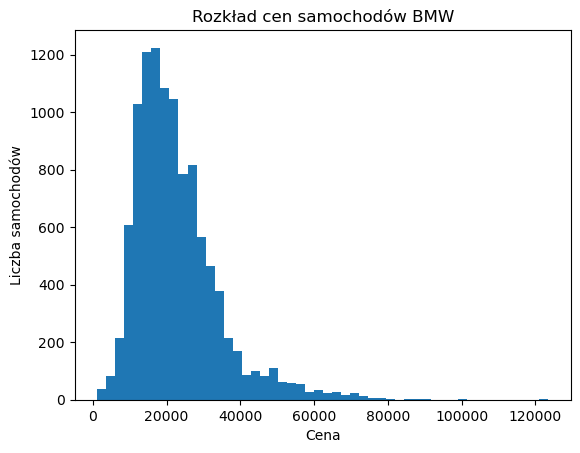

In [11]:
plt.figure()
plt.hist(prices, bins=50)
plt.xlabel("Cena")
plt.ylabel("Liczba samochodów")
plt.title("Rozkład cen samochodów BMW")
plt.show()

Histogram cen samochódów pokazuje, że moda wynosi nieco poniżej 20,000. Wyraźnie widać tu skośność prawostronną - niewielka liczba bardzo drogich modeli podnosi średnią cenę.

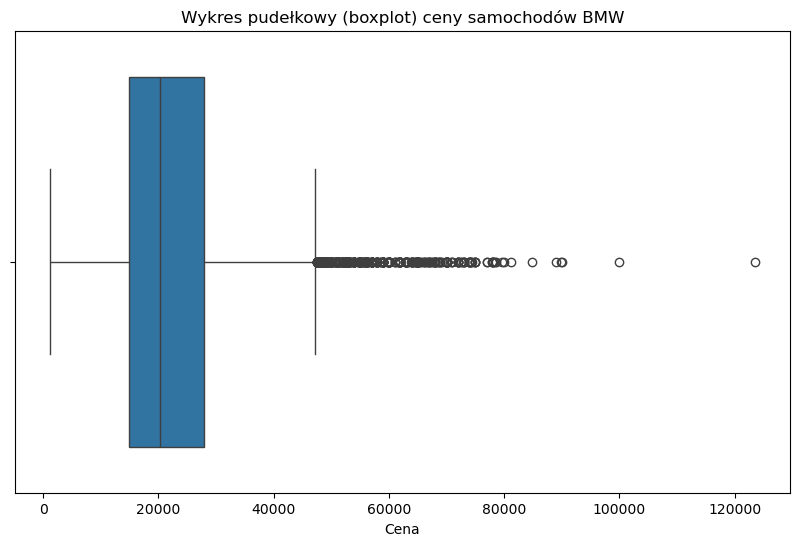

In [12]:
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.boxplot(x=prices)

plt.title("Wykres pudełkowy (boxplot) ceny samochodów BMW")
plt.xlabel("Cena")
plt.show()

Wykres Boxplot (wykres pudełkowy/wykres ramka-wąsy) ceny potwierdza obecność licznych wartości odstających po prawej stronie rozkładu, co oznacza występowanie bardzo drogich modeli BMW, zawyżających średnią.
Mediana ceny znajduje się znacznie poniżej wartości maksymalnych. 

Moda jest niższa od mediany, z kolei mediana jest niższa od średniej.
50% wartości się mieści w przedziale 15 tysięcy do 28 tysięcy. Nie występują wartości odstające po lewej stronie.

### Rok produkcji (Year)

In [13]:
df['year'].describe()

count   10664.00
mean     2017.06
std         2.35
min      1996.00
25%      2016.00
50%      2017.00
75%      2019.00
max      2020.00
Name: year, dtype: float64

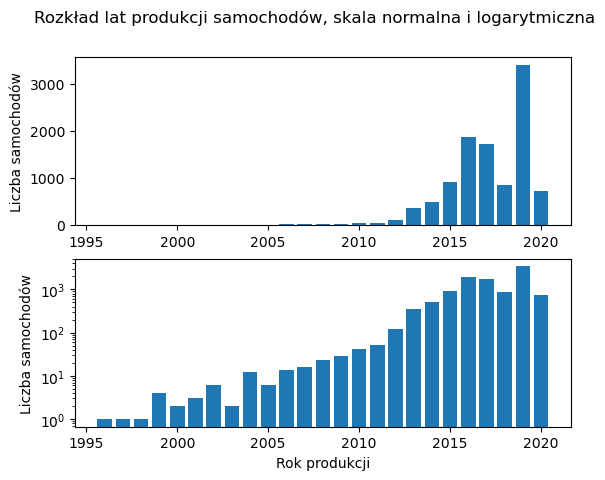

In [14]:
year_counts =df['year'].value_counts()
fig, axes = plt.subplots(2)

fig.suptitle("Rozkład lat produkcji samochodów, skala normalna i logarytmiczna")
axes[0].bar(year_counts.index, year_counts.values)
axes[0].set(ylabel = "Liczba samochodów")

axes[1].bar(year_counts.index, year_counts.values)
axes[1].set(xlabel="Rok produkcji", ylabel = "Liczba samochodów", yscale='log')

plt.show()

Większość aut pochodzi z lat 2016–2019, średni rok produkcji to 2017.

Wykres pudełkowy (ramka-wąsy) roku produkcji

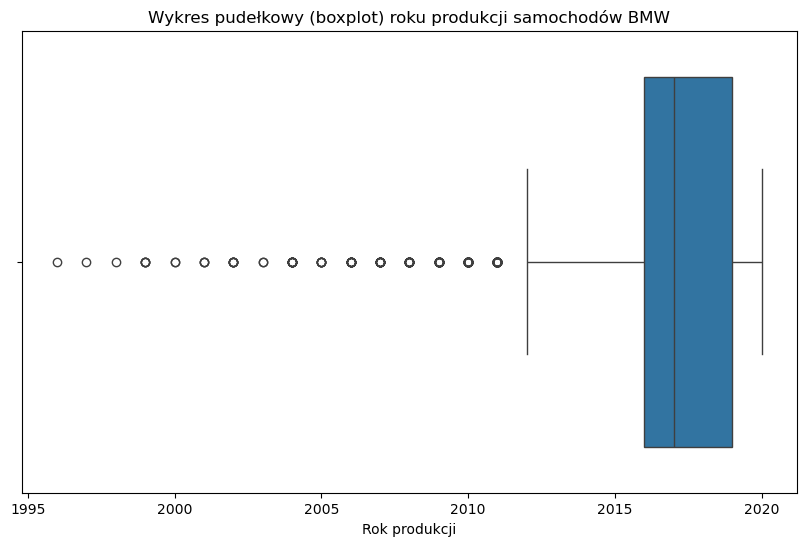

In [15]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['year'])

plt.title("Wykres pudełkowy (boxplot) roku produkcji samochodów BMW")
plt.xlabel("Rok produkcji")
plt.show()

In [16]:
series_year = df['year']
Q1 = series_year.quantile(0.25)
Q2 = series_year.quantile(0.50)
Q3 = series_year.quantile(0.75)

IQR = Q3 - Q1

lower_whisker = series_year[series_year >= Q1 - 1.5 * IQR].min()
upper_whisker = series_year[series_year <= Q3 + 1.5 * IQR].max()

minimum=series_year.min()
maximum=series_year.max()

outliers = series_year[(series_year < lower_whisker) | (series_year > upper_whisker)]

n=len(series_year)
print("Q1 (Kwantyl 0.25): ", Q1)
print("Mediana: ", Q2)
print("Q3 (Kwantyl 0.75): ", Q3)
print("IQR: ", IQR)
print("Dolny wąs: ", lower_whisker)
print("Górny wąs: ", upper_whisker)
print("Wartość minimalna: ", minimum)
print("Wartość maksymalna: ", maximum)
print(f"Liczba wartości odstających: {outliers.count()} co stanowi {outliers.count()*100/n:.2f}%")

Q1 (Kwantyl 0.25):  2016.0
Mediana:  2017.0
Q3 (Kwantyl 0.75):  2019.0
IQR:  3.0
Dolny wąs:  2012
Górny wąs:  2020
Wartość minimalna:  1996
Wartość maksymalna:  2020
Liczba wartości odstających: 212 co stanowi 1.99%


### Przebieg (Mileage)

In [17]:
df['mileage'].describe()

count    10664.00
mean     25710.98
std      25146.63
min          1.00
25%       5665.75
50%      18783.00
75%      38436.50
max     214000.00
Name: mileage, dtype: float64

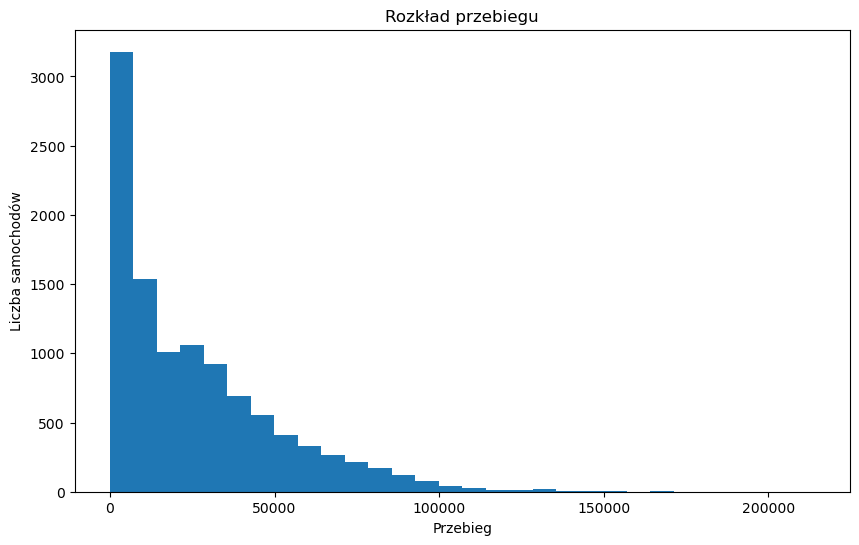

In [18]:
plt.figure(figsize=(10, 6))
plt.hist(df['mileage'], bins=30)
plt.xlabel("Przebieg")
plt.ylabel("Liczba samochodów")
plt.title("Rozkład przebiegu")
plt.show()

Z histogramu wynika, że moda przebiegu wynosi 0, więc można stwierdzić, że większość aut jest nowa.

### Rozmiar silnika (Engine Size)

In [19]:
print(df['engineSize'].describe())

count   10664.00
mean        2.17
std         0.55
min         0.00
25%         2.00
50%         2.00
75%         2.00
max         6.60
Name: engineSize, dtype: float64


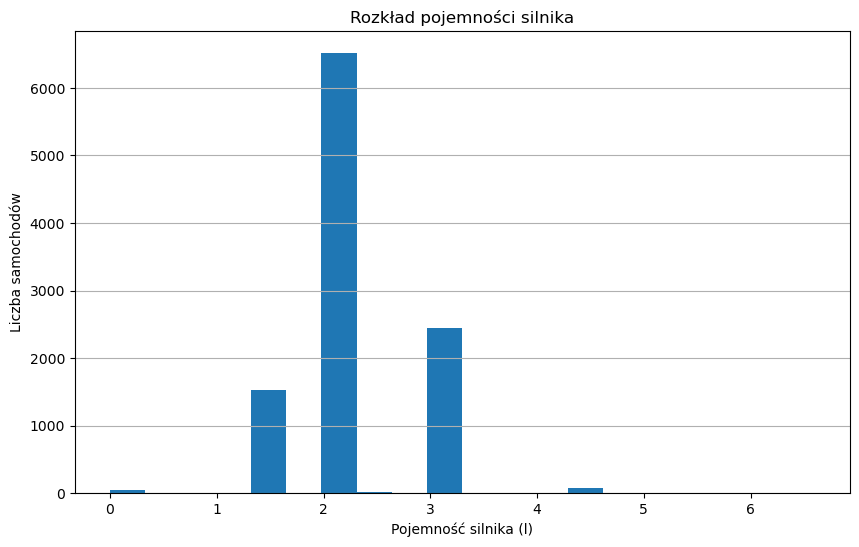

In [20]:
plt.figure(figsize=(10, 6))
plt.hist(df['engineSize'], bins=20)
plt.xlabel("Pojemność silnika (l)")
plt.ylabel("Liczba samochodów")
plt.title("Rozkład pojemności silnika")
plt.grid(axis='y')
plt.show()

### Zużycie paliwa (Mpg)

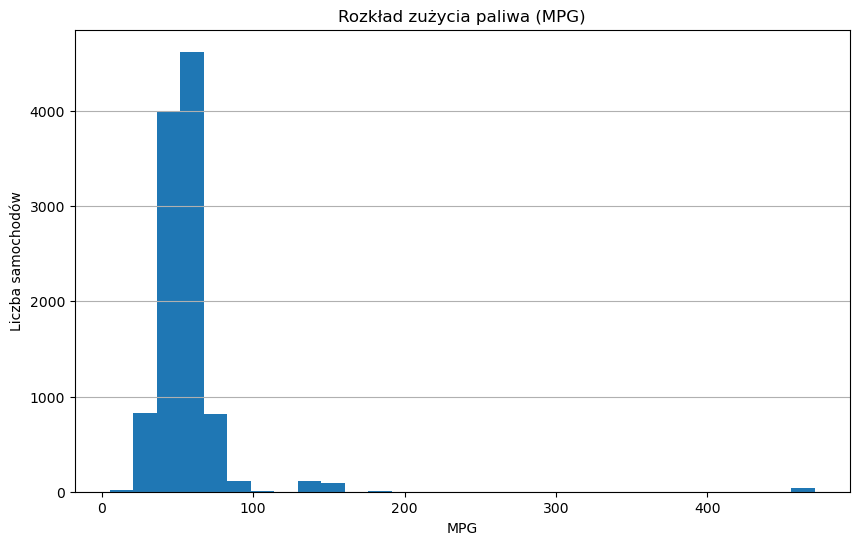

In [21]:
plt.figure(figsize=(10, 6))
plt.hist(df['mpg'], bins=30)
plt.xlabel("MPG")
plt.ylabel("Liczba samochodów")
plt.title("Rozkład zużycia paliwa (MPG)")
plt.grid(axis='y')
plt.show()

### Podatek drogowy (tax)

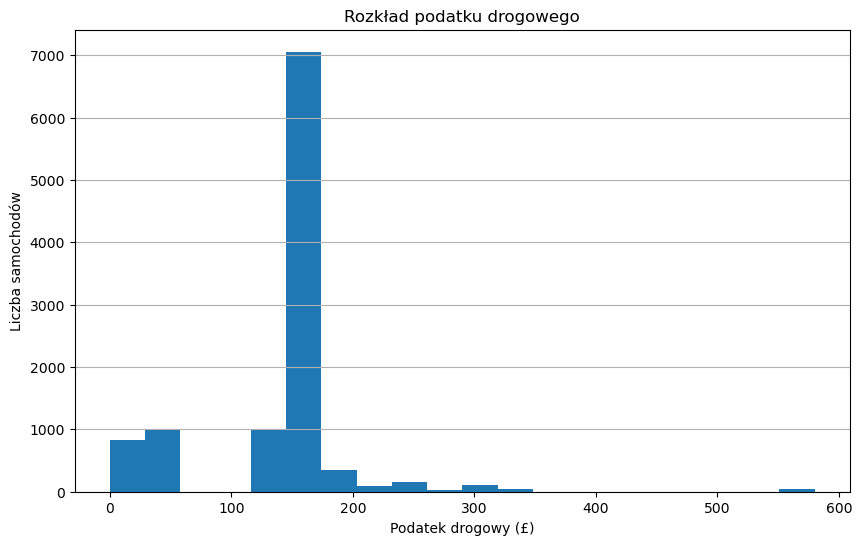

In [22]:
plt.figure(figsize=(10, 6))
plt.hist(df['tax'], bins=20)
plt.xlabel("Podatek drogowy (£)")
plt.ylabel("Liczba samochodów")
plt.title("Rozkład podatku drogowego")
plt.grid(axis='y')
plt.show()

### Zmienne kategoryczne

### Model

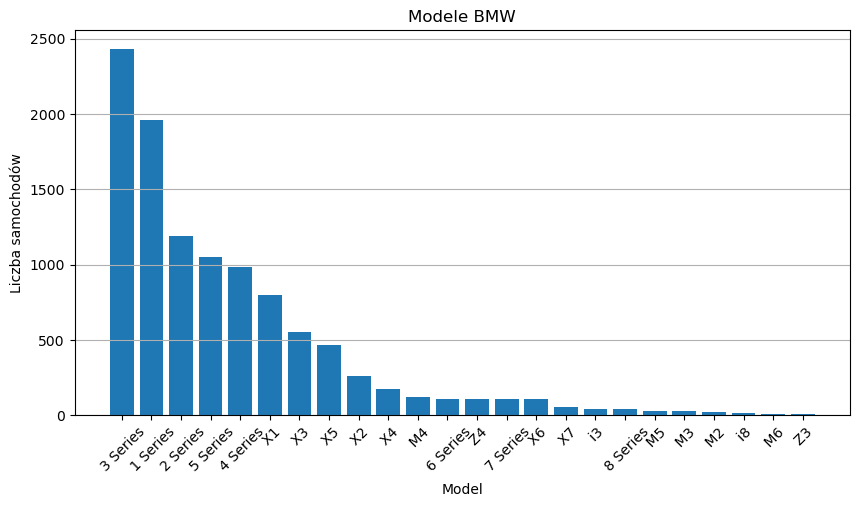

In [23]:
model_counts = df['model'].value_counts()

plt.figure(figsize=(10,5))
plt.bar(model_counts.index, model_counts.values)
plt.xlabel("Model")
plt.ylabel("Liczba samochodów")
plt.title("Modele BMW")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

### Rodzaj skrzyni biegów (Transmission)

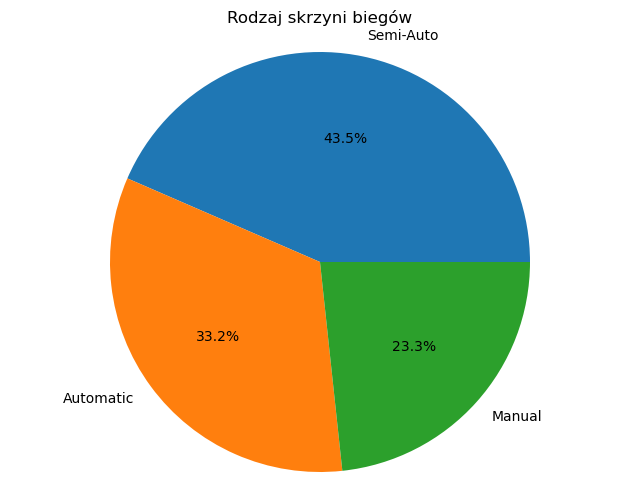

In [24]:
transmission_counts = df['transmission'].value_counts()

plt.figure(figsize=(8, 6))
plt.pie(transmission_counts,
        labels=transmission_counts.index, autopct='%1.1f%%' )
plt.title("Rodzaj skrzyni biegów")
plt.axis('equal')
plt.show()


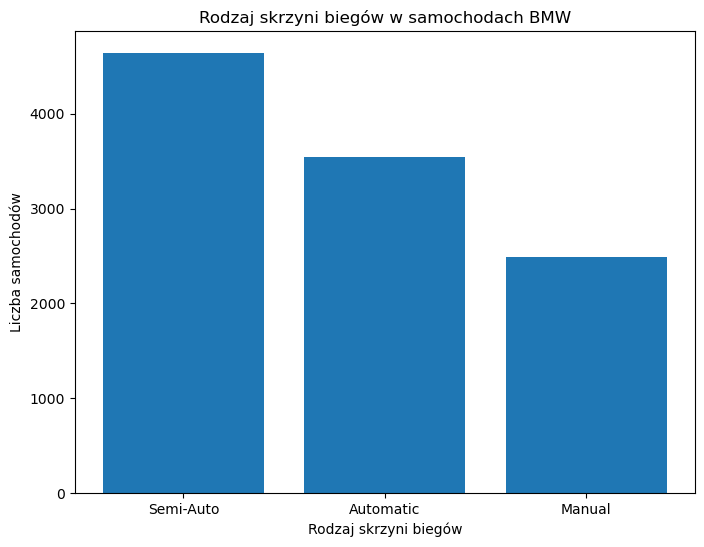

In [25]:
plt.figure(figsize=(8, 6))
plt.bar(transmission_counts.index, transmission_counts.values)
plt.xlabel("Rodzaj skrzyni biegów")
plt.ylabel("Liczba samochodów")
plt.title("Rodzaj skrzyni biegów w samochodach BMW")
plt.show()

### Rodzaj paliwa (FuelType)

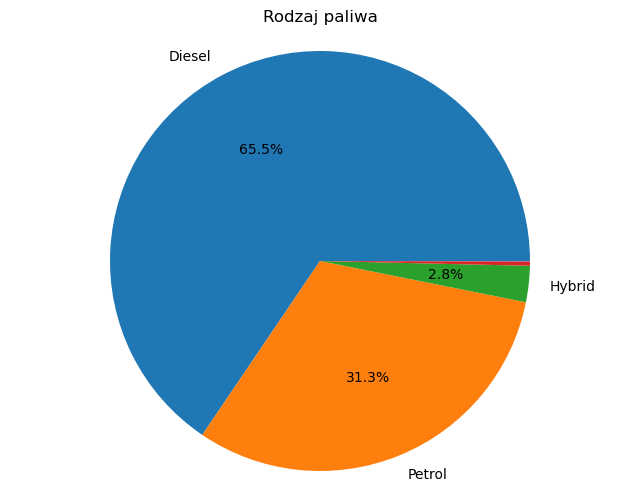

In [26]:
fuel_counts = df['fuelType'].value_counts()


def hide_labels_for_small_percentages(pct):
    return f'{pct:.1f}%' if pct >= 1 else ''


total = fuel_counts.sum()
filtered_labels = [
    label if (count / total * 100) >= 1 else ''
    for label, count in zip(fuel_counts.index, fuel_counts.values)
]

plt.figure(figsize=(8, 6))
plt.pie(fuel_counts,
        labels=filtered_labels, autopct=hide_labels_for_small_percentages )
plt.title("Rodzaj paliwa")
plt.axis('equal')
plt.show()


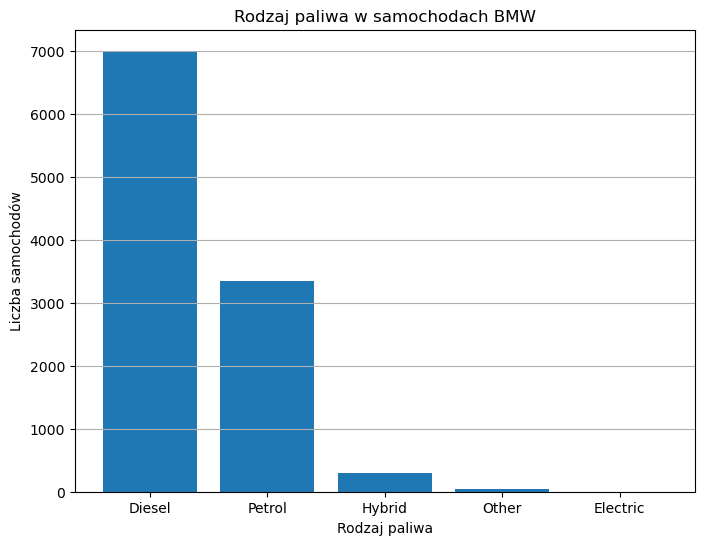

In [27]:
plt.figure(figsize=(8, 6))
plt.bar(fuel_counts.index, fuel_counts.values)
plt.xlabel("Rodzaj paliwa")
plt.ylabel("Liczba samochodów")
plt.title("Rodzaj paliwa w samochodach BMW")
plt.grid(axis='y')
plt.show()

## 1.4 Analiza zależności między zmiennymi

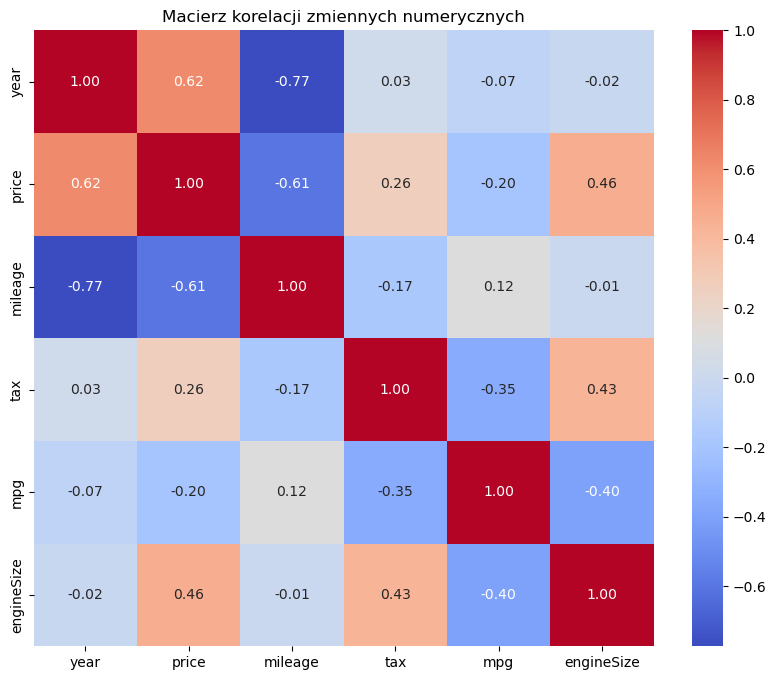

In [28]:
import seaborn as sns
import numpy as np

df_numeric = df.select_dtypes(include=['int64', 'float64'])

corr_matrix = df_numeric.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix,
            annot=True,
            fmt=".2f",
            cmap="coolwarm")

plt.title("Macierz korelacji zmiennych numerycznych")
plt.show()

Pairplot zmiennych numerycznych

<Figure size 1000x800 with 0 Axes>

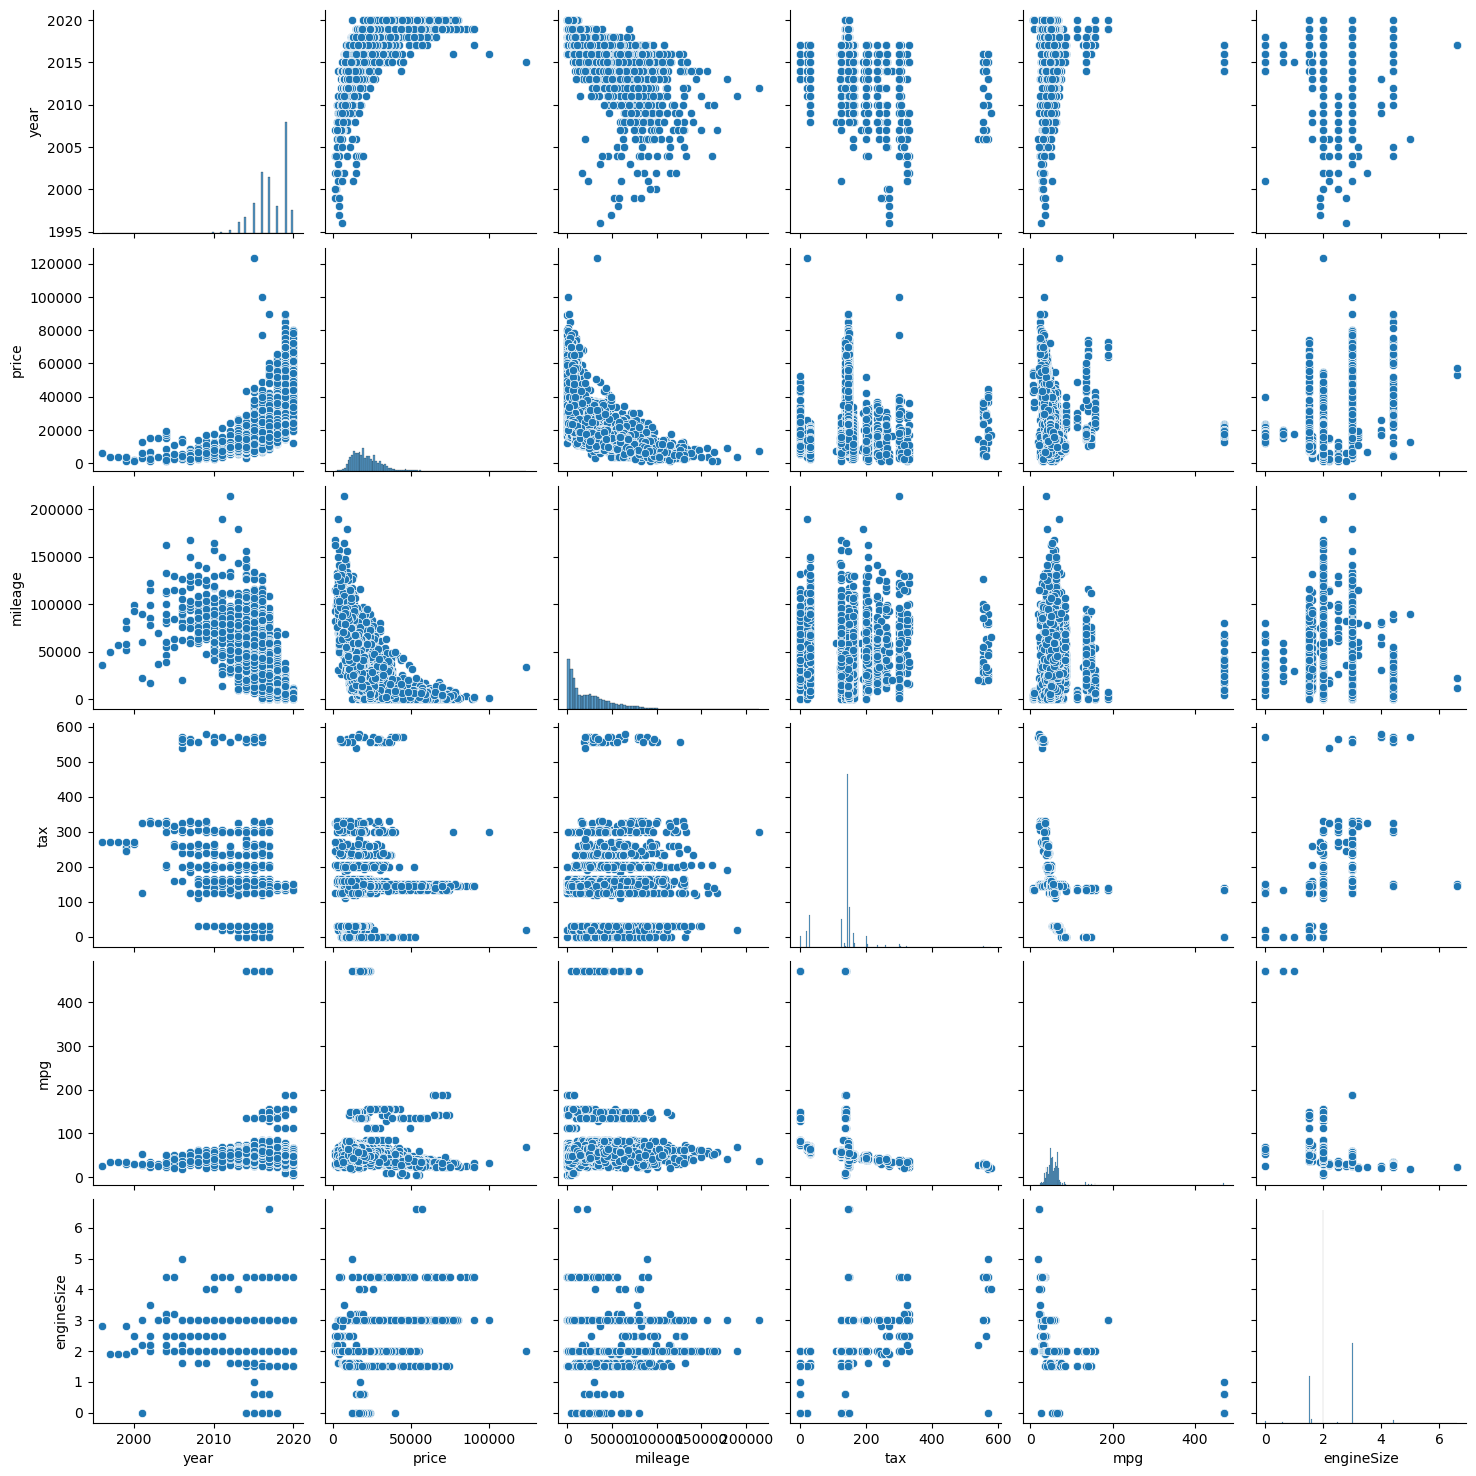

In [29]:
plt.figure(figsize=(10, 8))
sns.pairplot(df_numeric)
plt.show()

Cena a rok produkcji

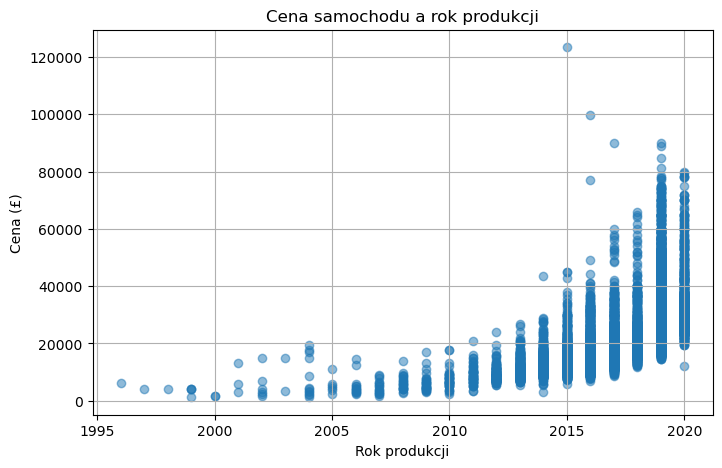

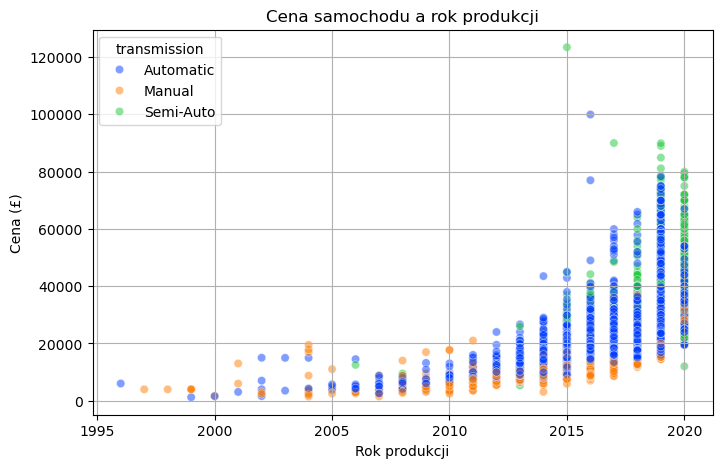

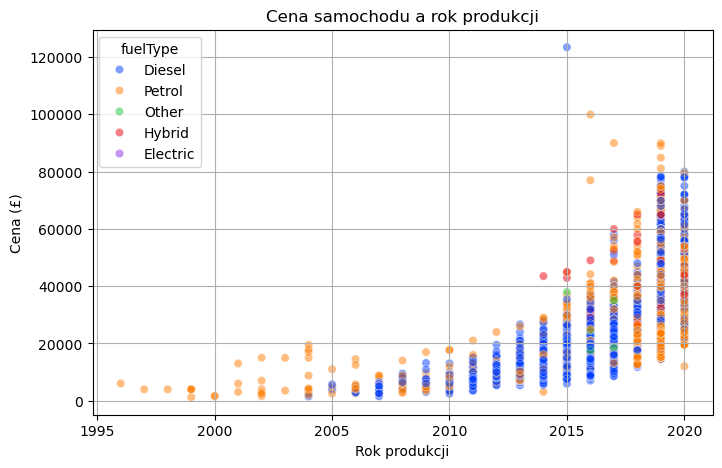

In [30]:
plt.figure(figsize=(8,5))
plt.scatter(df['year'], df['price'], alpha=0.5)
plt.xlabel("Rok produkcji")
plt.ylabel("Cena (£)")
plt.title("Cena samochodu a rok produkcji")
plt.grid()
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='year', y='price', hue='transmission', palette='bright', alpha=0.5)
plt.xlabel("Rok produkcji")
plt.ylabel("Cena (£)")
plt.title("Cena samochodu a rok produkcji")
plt.grid()
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='year', y='price', hue='fuelType', palette='bright', alpha=0.5)
plt.xlabel("Rok produkcji")
plt.ylabel("Cena (£)")
plt.title("Cena samochodu a rok produkcji")
plt.grid()
plt.show()

Wraz ze wzrostem roku produkcji rośnie średnia cena pojazdu. Można zauważyć zwiększenie liczby samochodów ze skrzynią półautomatyczną w nowszych rocznikach. 
Stwórzmy wykresy kołowe skrzyni biegów dla różnych lat.

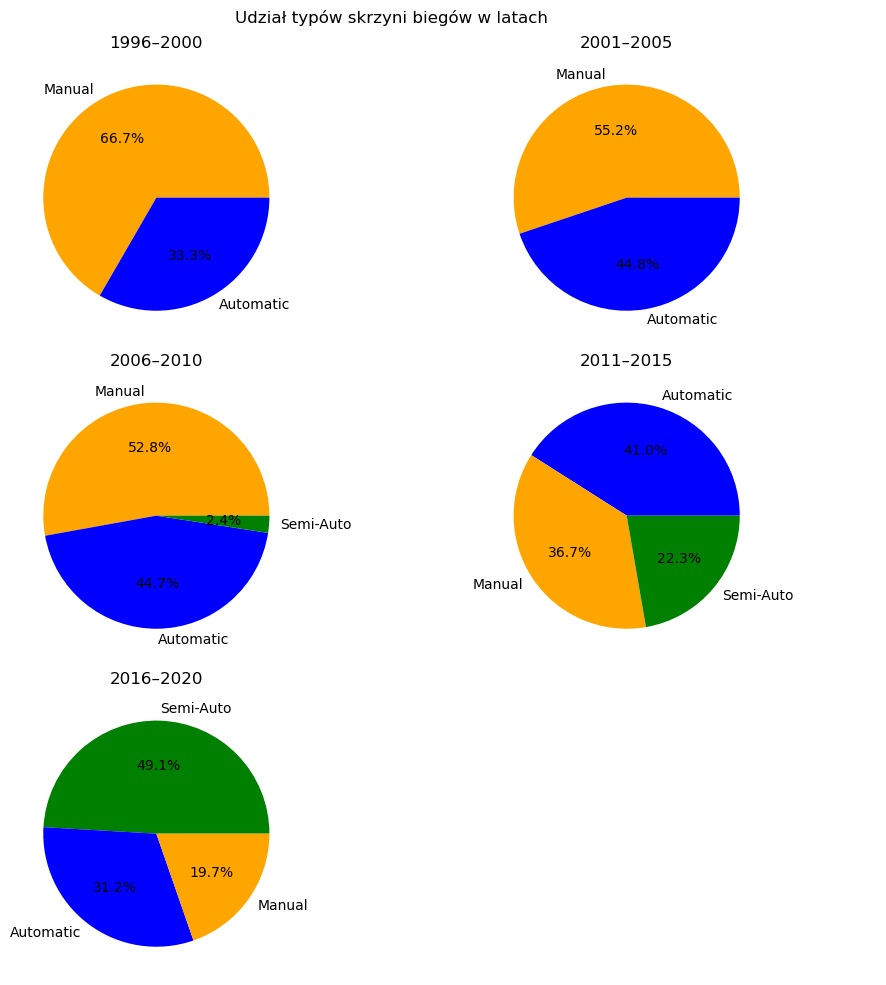

In [31]:
ranges = [
    (1996, 2000),
    (2001, 2005),
    (2006, 2010),
    (2011, 2015),
    (2016, 2020)
]

colors_map = {
    'Automatic': 'blue',
    'Semi-Auto': 'green',
    'Manual': 'orange'
}

fig, axes = plt.subplots(3, 2, figsize=(10, 10))
axes = axes.flatten()

for ax, (start, end) in zip(axes, ranges):
    data = df[(df['year'] >= start) & (df['year'] <= end)]
    counts = data['transmission'].value_counts()
    colors = [colors_map[t] for t in counts.index]

    ax.pie(counts, labels=counts.index, colors=colors, autopct='%1.1f%%')
    ax.set_title(f"{start}–{end}")

for ax in axes[len(ranges):]:
    ax.axis('off')

plt.suptitle("Udział typów skrzyni biegów w latach")
plt.tight_layout()
plt.show()

Można zauważyć wzrost popularności skrzyni automatycznej i półautomatycznej i spadek skrzyni manualnej.

Cena a przebieg

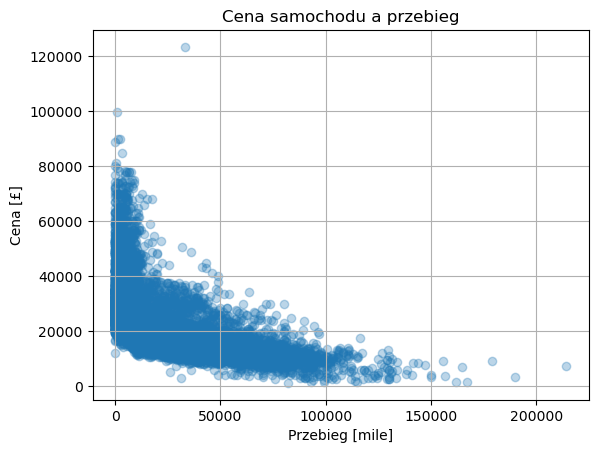

In [32]:
plt.figure()
plt.scatter(df['mileage'], df['price'], alpha=0.3)
plt.xlabel("Przebieg [mile]")
plt.ylabel("Cena [£]")
plt.title("Cena samochodu a przebieg")
plt.grid()
plt.show()

Cena w zależności od rodzaju paliwa

fuelType
Diesel     21749.45
Electric   18466.00
Hybrid     27154.97
Other      18193.86
Petrol     24322.28
Name: price, dtype: float64


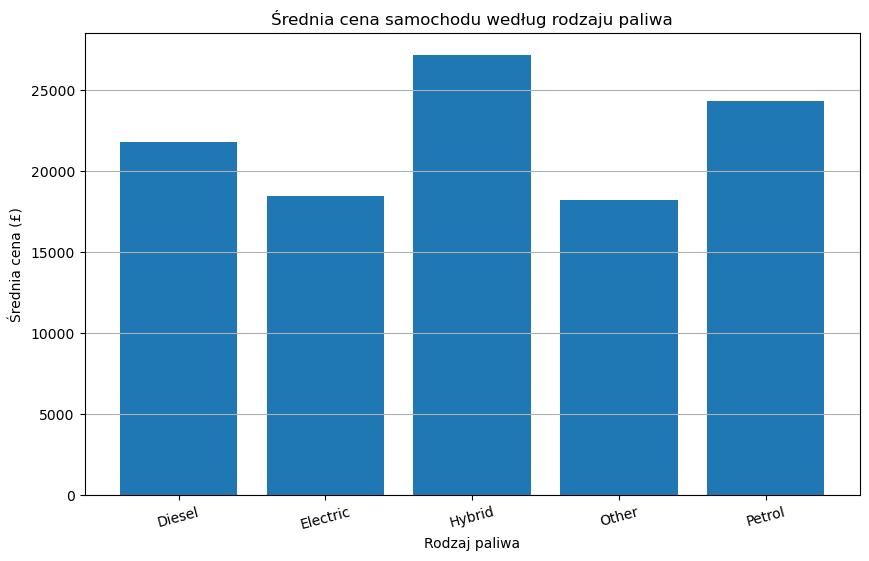

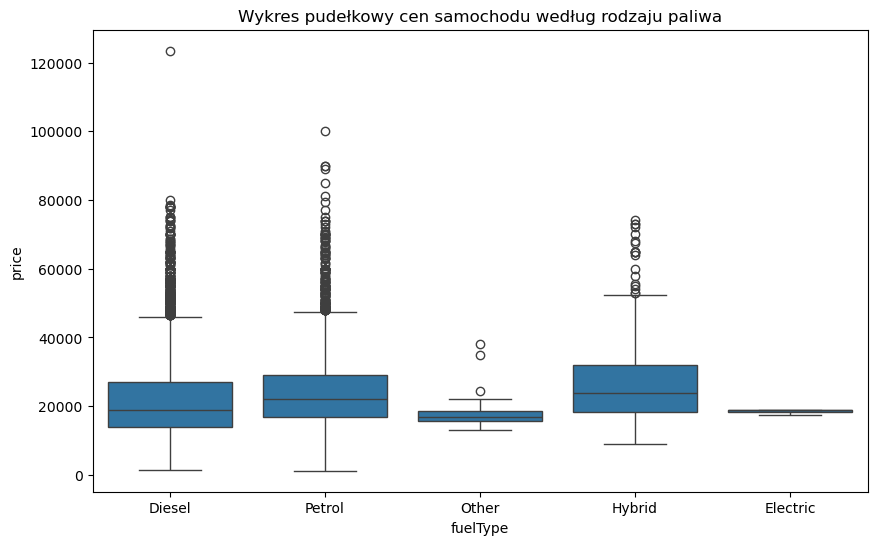

In [33]:
avg_price_fuel = df.groupby('fuelType')['price'].mean()
print(avg_price_fuel)
plt.figure(figsize=(10,6))
plt.bar(avg_price_fuel.index, avg_price_fuel.values)
plt.xlabel("Rodzaj paliwa")
plt.xticks(rotation=15)
plt.ylabel("Średnia cena (£)")
plt.title("Średnia cena samochodu według rodzaju paliwa")
plt.grid(axis='y')
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(
    x="fuelType",
    y="price",
    data=df
)
plt.title("Wykres pudełkowy cen samochodu według rodzaju paliwa")
plt.show()

Najdroższe okazały się samochody hybrydowe, a najtańsze elektryczne oraz oznaczone jako inne (Other). Może być to związane z małą liczbą rekordów, gdyż w zbiorze były tylko 3 samochody elektryczne i 36 samochody other.

# **2. Testy parametryczne**

## 2.1 Test t-studenta

**Hipoteza zerowa (H₀):**

Średnia cena samochodów BMW z silnikiem Diesla jest taka sama jak średnia cena samochodów BMW z silnikiem benzynowym.

**Hipoteza alternatywna (H₁):**

Średnia cena samochodów BMW z silnikiem Diesla różni się od średniej ceny samochodów BMW z silnikiem benzynowym.

**Wymóg 1: Niezależność prób**

Samochody z silnikiem Diesla i benzynowym stanowią dwie odrębne grupy, a każda obserwacja występuje tylko raz w zbiorze danych.

**Wymóg 2: Rozkład zmiennej zbliżony do normalnego**

Sprawdzono normalność rozkładu ceny w obu grupach za pomocą testu Shapiro-Wilka.

In [34]:
from scipy.stats import shapiro

df = pd.read_csv("bmw.csv")

diesel_prices = df[df["fuelType"] == "Diesel"]["price"]
petrol_prices = df[df["fuelType"] == "Petrol"]["price"]

shapiro_diesel = shapiro(diesel_prices.sample(500, random_state=1))
shapiro_petrol = shapiro(petrol_prices.sample(500, random_state=1))

print("Diesel p-value:", shapiro_diesel.pvalue)
print("Petrol p-value:", shapiro_petrol.pvalue)

Diesel p-value: 1.891785062458934e-20
Petrol p-value: 1.4955499929705802e-15


Otrzymane wartości p-value dla obu grup są znacznie mniejsze od poziomu istotności α = 0,05, co wskazuje na brak normalności rozkładów.

Pomimo niespełnienia tego założenia, ze względu na dużą liczebność prób zastosowano test t-Studenta w wersji Welcha, który jest odporny na naruszenie założenia normalności oraz nie wymaga równości wariancji.

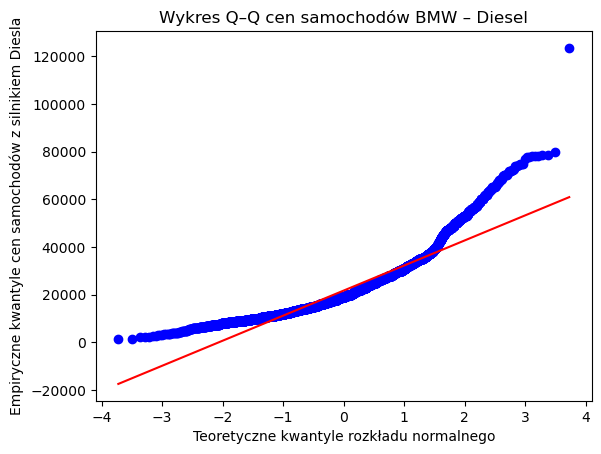

In [35]:
diesel_prices = df[df["fuelType"] == "Diesel"]["price"]
petrol_prices = df[df["fuelType"] == "Petrol"]["price"]

plt.figure()
stats.probplot(diesel_prices, dist="norm", plot=plt)
plt.xlabel("Teoretyczne kwantyle rozkładu normalnego")
plt.ylabel("Empiryczne kwantyle cen samochodów z silnikiem Diesla")
plt.title("Wykres Q–Q cen samochodów BMW – Diesel")
plt.show()

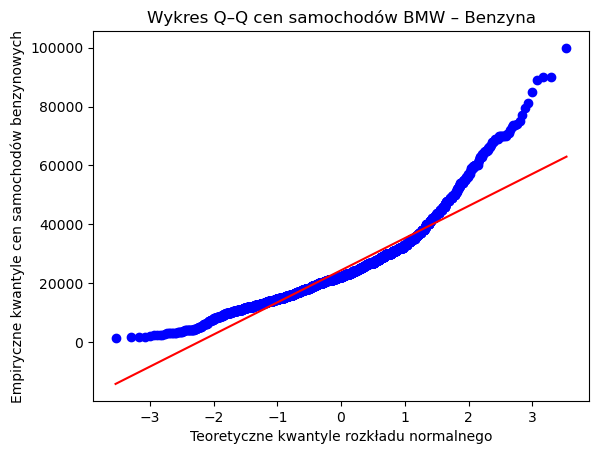

In [36]:
plt.figure()
stats.probplot(petrol_prices, dist="norm", plot=plt)
plt.xlabel("Teoretyczne kwantyle rozkładu normalnego")
plt.ylabel("Empiryczne kwantyle cen samochodów benzynowych")
plt.title("Wykres Q–Q cen samochodów BMW – Benzyna")
plt.show()

**Wynik testu**

In [37]:
from scipy.stats import ttest_ind

df = pd.read_csv("bmw.csv")

diesel_prices = df[df["fuelType"] == "Diesel"]["price"]
petrol_prices = df[df["fuelType"] == "Petrol"]["price"]

t_stat, p_value = ttest_ind(
    diesel_prices,
    petrol_prices,
    equal_var=False   # test Welcha
)

print("Statystyka t:", t_stat)
print("p-value:", p_value)

Statystyka t: -10.837347932657433
p-value: 3.8741272635144404e-27


Przy poziomie istotności α = 0,05 otrzymana wartość p-value ≈ 3,87·10⁻²⁷ jest znacznie mniejsza od przyjętego poziomu istotności. Oznacza to, że różnica średnich cen samochodów z silnikiem Diesla i benzynowych jest istotna statystycznie.

W związku z powyższym odrzucono hipotezę zerową, zgodnie z którą średnie ceny obu grup są równe. Ujemna wartość statystyki t wskazuje, że średnia cena samochodów z silnikiem Diesla jest niższa niż średnia cena samochodów benzynowych.

# **3. Test ANOVA**

Analiza wariancji została zastosowana w celu porównania średnich cen samochodów BMW pomiędzy różnymi grupami rodzaju paliwa.

**Hipoteza zerowa (H₀):**

Średnie ceny samochodów BMW są jednakowe we wszystkich grupach rodzaju paliwa.

**Hipoteza alternatywna (H₁):**

Co najmniej jedna z grup różni się istotnie statystycznie pod względem średniej ceny.

**Wymóg 1: Niezależność obserwacji**

Każdy samochód występuje w zbiorze danych tylko raz i należy do jednej grupy paliwa.

**Wymóg 2: Normalność rozkładu w grupach**

Normalność rozkładu zmiennej cena w poszczególnych grupach rodzaju paliwa została zweryfikowana we wcześniejszym etapie analizy i wykazano istotne odstępstwa od rozkładu normalnego.

**Wymóg 3: Jednorodność wariancji**

Sprawdzono równość wariancji za pomocą testu Levene’a.

In [38]:
from scipy.stats import levene

groups = [
    df[df["fuelType"] == fuel]["price"]
    for fuel in df["fuelType"].unique()
]

levene_test = levene(*groups)

print("Levene p-value:", levene_test.pvalue)

Levene p-value: 0.00016008357888507488


 Otrzymana wartość p-value = 0,00016 jest mniejsza od przyjętego poziomu istotności α = 0,05, co wskazuje na istotne statystycznie różnice wariancji pomiędzy grupami.

W związku z niespełnieniem założenia jednorodności wariancji zdecydowano się na zastosowanie analizy wariancji ANOVA w wersji Welcha, która nie wymaga spełnienia tego założenia.

In [39]:
#!pip install pingouin
import pingouin as pg

welch_anova = pg.welch_anova(
    data=df,
    dv="price",
    between="fuelType"
)

print(welch_anova)

     Source  ddof1  ddof2     F  p_unc  np2
0  fuelType      4  16.26 53.87   0.00 0.02


Otrzymany wynik wskazuje, że co najmniej jedna z analizowanych grup rodzaju paliwa różni się istotnie statystycznie pod względem średniej ceny, co potwierdza istotny wpływ rodzaju paliwa na cenę pojazdu.

W celu identyfikacji par grup różniących się istotnie statystycznie zastosowano test post-hoc Gamesa–Howella.

In [40]:
games_howell = pg.pairwise_gameshowell(
    data=df,
    dv="price",
    between="fuelType"
)

print(games_howell)

          A         B   mean_A   mean_B     diff      se      T      df  pval  \
0    Diesel  Electric 21779.26 18466.00  3313.26  549.47   6.03    2.26  0.06   
1    Diesel    Hybrid 21779.26 27169.71 -5390.45  744.43  -7.24  317.06  0.00   
2    Diesel     Other 21779.26 18193.86  3585.40  852.98   4.20   36.78  0.00   
3    Diesel    Petrol 21779.26 24360.27 -2581.01  238.16 -10.84 6593.15  0.00   
4  Electric    Hybrid 18466.00 27169.71 -8703.71  905.78  -9.61   16.29  0.00   
5  Electric     Other 18466.00 18193.86   272.14  996.91   0.27   18.04  1.00   
6  Electric    Petrol 18466.00 24360.27 -5894.27  568.31 -10.37    2.58  0.01   
7    Hybrid     Other 27169.71 18193.86  8975.85 1116.28   8.04  101.08  0.00   
8    Hybrid    Petrol 27169.71 24360.27  2809.44  758.44   3.70  341.47  0.00   
9     Other    Petrol 18193.86 24360.27 -6166.41  865.24  -7.13   38.94  0.00   

   hedges  
0    0.30  
1   -0.48  
2    0.32  
3   -0.23  
4   -0.69  
5    0.05  
6   -0.51  
7    0.74  


Przeprowadzona analiza statystyczna wykazała, że rodzaj paliwa ma istotny wpływ na cenę samochodów BMW, przy czym najwyższe średnie ceny odnotowano dla pojazdów hybrydowych, a najniższe dla pojazdów elektrycznych oraz z grupy „Other”.

# **4. Testy nieparametryczne**

Z racji nienormalności rozkładów zastosowano również testy nieparametryczne.

## 4.1 Test Manna–Whitneya

**Hipoteza zerowa (H₀):**

Rozkłady cen samochodów Diesla i benzynowych są takie same.




**Hipoteza alternatywna (H₁):**

Rozkłady cen różnią się istotnie statystycznie.

In [41]:
from scipy.stats import mannwhitneyu

u_stat, mw_p = mannwhitneyu(
    diesel_prices,
    petrol_prices,
    alternative="two-sided"
)

print("Mann–Whitney U:", u_stat)
print("p-value:", mw_p)

Mann–Whitney U: 9958342.0
p-value: 1.5866096359458147e-45


Wartość p jest mniejsza od poziomu istotności, co potwierdza istotne różnice cen pomiędzy analizowanymi grupami.

## 4.2 Test Kruskala–Wallisa

Test Kruskala–Wallisa jest nieparametrycznym odpowiednikiem testu ANOVA.

In [42]:
from scipy.stats import kruskal

kw_stat, kw_p = kruskal(*groups)

print("Kruskal–Wallis statystyka:", kw_stat)
print("p-value:", kw_p)

Kruskal–Wallis statystyka: 259.1712834335899
p-value: 6.879649237769231e-55


Otrzymany wynik wskazuje na istotne różnice pomiędzy co najmniej jedną z grup paliwa.

# **5. Analiza regresji wielorakowej**

Celem analizy regresji wielorakowej jest zbadanie wpływu wielu cech pojazdu jednocześnie na jego cenę.

In [43]:
import numpy as np
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

# Wybór kolumn do regresji i usunięcie braków
df_reg = df[
    ["price", "mileage", "year", "engineSize", "fuelType", "transmission"]
].dropna()

# Transformacja zmiennej objaśnianej
df_reg["log_price"] = np.log(df_reg["price"])

# Tworzenie zmiennych zero-jedynkowych dla kategorii
df_reg = pd.get_dummies(
    df_reg,
    columns=["fuelType", "transmission"],
    drop_first=True
)

# Oddziel zmienne objaśniające od zmiennej zależnej
y = df_reg["log_price"]
X = df_reg.drop(columns=["price", "log_price"])

# Standaryzacja zmiennych numerycznych
num_cols = ["mileage", "year", "engineSize"]
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

# Upewnij się, że wszystkie kolumny są float
X = X.astype(float)

# Dodanie stałej (intercept) do modelu
X = sm.add_constant(X)

# Dopasowanie modelu
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.839
Model:                            OLS   Adj. R-squared:                  0.839
Method:                 Least Squares   F-statistic:                     6244.
Date:                Sun, 08 Mar 2026   Prob (F-statistic):               0.00
Time:                        22:30:52   Log-Likelihood:                 2403.5
No. Observations:               10781   AIC:                            -4787.
Df Residuals:                   10771   BIC:                            -4714.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      9

Model jako całość jest istotny statystycznie, co potwierdza wynik testu F (F=6244). Współczynnik determinacji R-kwadrat (0.839) wskazuje, że znaczna część zmienności ceny jest wyjaśniana przez zmienne zawarte w modelu.

## Diagnostyka modelu (diagnostyka reszt)

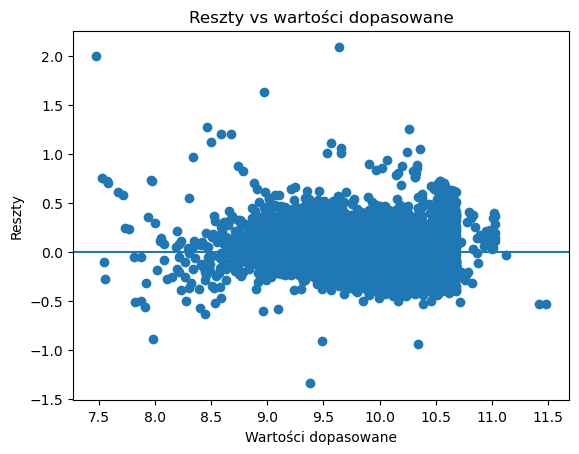

Shapiro reszt p-value: 6.023576335727646e-19
Breusch–Pagan p-value: 2.5205550572691677e-131


In [44]:
from statsmodels.stats.diagnostic import het_breuschpagan

residuals = model.resid
fitted = model.fittedvalues

plt.figure()
plt.scatter(fitted, residuals)
plt.axhline(0)
plt.xlabel("Wartości dopasowane")
plt.ylabel("Reszty")
plt.title("Reszty vs wartości dopasowane")
plt.show()

shapiro_res = shapiro(residuals.sample(500, random_state=1))
print("Shapiro reszt p-value:", shapiro_res.pvalue)

bp_test = het_breuschpagan(residuals, model.model.exog)
print("Breusch–Pagan p-value:", bp_test[1])

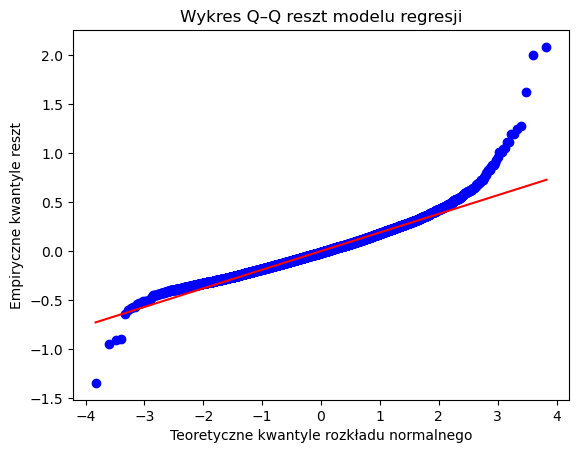

In [45]:
plt.figure()
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Wykres Q–Q reszt modelu regresji")
plt.xlabel("Teoretyczne kwantyle rozkładu normalnego")
plt.ylabel("Empiryczne kwantyle reszt")
plt.show()

Analiza reszt wskazuje na możliwe naruszenie założeń modelu, co uzasadnia jego uproszczenie.

In [46]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif["zmienna"] = X.columns
vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif)

                  zmienna  VIF
0                   const 3.71
1                 mileage 2.69
2                    year 2.61
3              engineSize 1.19
4       fuelType_Electric 1.01
5         fuelType_Hybrid 1.06
6          fuelType_Other 1.01
7         fuelType_Petrol 1.10
8     transmission_Manual 1.51
9  transmission_Semi-Auto 1.45


Na podstawie istotności parametrów oraz wartości VIF usunięto zmienne nieistotne statystycznie.

In [47]:
model.pvalues

const                    0.00
mileage                  0.00
year                     0.00
engineSize               0.00
fuelType_Electric        0.00
fuelType_Hybrid          0.00
fuelType_Other           0.00
fuelType_Petrol          0.00
transmission_Manual      0.00
transmission_Semi-Auto   0.89
dtype: float64

In [48]:
X_reduced = X.drop(
    columns=[
        col for col in X.columns
        if col != "const" and model.pvalues[col] > 0.05
    ]
)

print(X.columns)
print(X_reduced.columns)
model_reduced = sm.OLS(y, X_reduced).fit()
print(model_reduced.summary())

print("R2 model pełny:", model.rsquared)
print("R2 model uproszczony:", model_reduced.rsquared)
print("AIC model pełny:", model.aic)
print("AIC model uproszczony:", model_reduced.aic)
print("BIC pełny:", model.bic)
print("BIC uproszczony:", model_reduced.bic)
print("Liczba parametrów – model pełny:", model.df_model)
print("Liczba parametrów – model uproszczony:", model_reduced.df_model)

Index(['const', 'mileage', 'year', 'engineSize', 'fuelType_Electric',
       'fuelType_Hybrid', 'fuelType_Other', 'fuelType_Petrol',
       'transmission_Manual', 'transmission_Semi-Auto'],
      dtype='object')
Index(['const', 'mileage', 'year', 'engineSize', 'fuelType_Electric',
       'fuelType_Hybrid', 'fuelType_Other', 'fuelType_Petrol',
       'transmission_Manual'],
      dtype='object')
                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.839
Model:                            OLS   Adj. R-squared:                  0.839
Method:                 Least Squares   F-statistic:                     7025.
Date:                Sun, 08 Mar 2026   Prob (F-statistic):               0.00
Time:                        22:30:53   Log-Likelihood:                 2403.5
No. Observations:               10781   AIC:                            -4789.
Df Residuals:                   10772   BIC:     

Uproszczenie modelu regresji poprzez usunięcie zmiennych nieistotnych statystycznie nie spowodowało istotnego spadku współczynnika determinacji R², który pozostał na poziomie około 0.839. Jednocześnie zaobserwowano spadek wartości kryterium informacyjnego AIC o około 2, co zgodnie z przyjętymi regułami interpretacyjnymi oznacza, że oba modele są statystycznie porównywalne. z minimalnie lepszą jakością modelu uproszczonego przy mniejszej liczbie parametrów. Oznacza to, że zmienne usunięte z modelu nie wnosiły istotnej informacji wyjaśniającej, a model uproszczony jest bardziej interpretowalny i stabilny.